## Lab 8- Introduction to Machine Learning
Based on Chapter 2 from Geron's book, Hands-on Machine Learning with Scikit-Learn Keras & Tensorflow

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/dtrad/geoml_course/blob/master/Practice8-IntroToML.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

In [130]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os
print('directory',os.environ['PWD'])
# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "end_to_end_project"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

directory /home/dtrad/pythonexamples


## Loading and examining data

In [131]:
import os
import tarfile
import urllib.request

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

In [7]:
fetch_housing_data()

In [8]:
!ls datasets/housing

housing.csv  housing.tgz


In [13]:
import pandas as pd

def load_housing_data(housing_path=HOUSING_PATH):    
    csv_path = os.path.join(housing_path, "housing.csv")
    print("reading %s"%csv_path)
    return pd.read_csv(csv_path)

In [19]:
housing=load_housing_data()
print("created a panda object",type(housing))
housing.head()

reading datasets/housing/housing.csv
created a panda object <class 'pandas.core.frame.DataFrame'>


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [20]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [21]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [22]:
housing.ocean_proximity

0        NEAR BAY
1        NEAR BAY
2        NEAR BAY
3        NEAR BAY
4        NEAR BAY
           ...   
20635      INLAND
20636      INLAND
20637      INLAND
20638      INLAND
20639      INLAND
Name: ocean_proximity, Length: 20640, dtype: object

In [23]:
housing.ocean_proximity.value_counts()

<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: ocean_proximity, dtype: int64

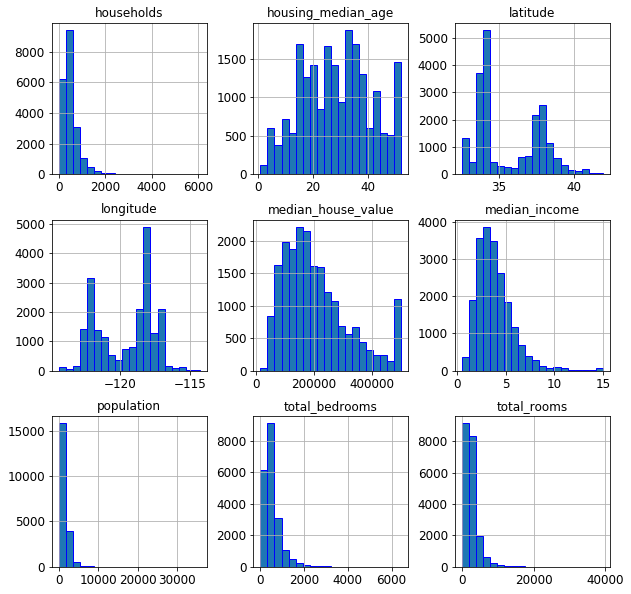

In [24]:
housing.hist(bins=20,figsize=(10,10),edgecolor='b')
plt.show()

In [25]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

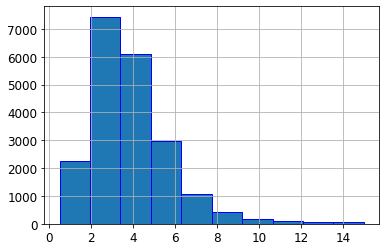

In [26]:
housing["median_income"].hist(edgecolor='b')

In [27]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [28]:
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

In [29]:
(housing.keys())

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'income_cat'],
      dtype='object')

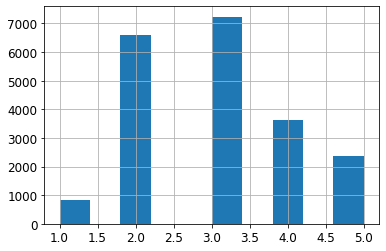

In [30]:
housing.income_cat.hist()

Let us use a Stratified ShuffleSplit cross-validator that provides train/test indices to split data in train/test sets.

In [31]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

In [32]:
split?

Type:        StratifiedShuffleSplit
String form:
StratifiedShuffleSplit(n_splits=1, random_state=42, test_size=0.2,
            train_size=None)
File:        ~/anaconda3/envs/tfgpu2/lib/python3.7/site-packages/sklearn/model_selection/_split.py
Docstring:  
Stratified ShuffleSplit cross-validator

Provides train/test indices to split data in train/test sets.

This cross-validation object is a merge of StratifiedKFold and
ShuffleSplit, which returns stratified randomized folds. The folds
are made by preserving the percentage of samples for each class.

Note: like the ShuffleSplit strategy, stratified random splits
do not guarantee that all folds will be different, although this is
still very likely for sizeable datasets.

Read more in the :ref:`User Guide <cross_validation>`.

Parameters
----------
n_splits : int, default 10
    Number of re-shuffling & splitting iterations.

test_size : float, int, None, optional (default=None)
    If float, should be between 0.0 and 1.0 and represent t

In [33]:
type(strat_train_set),type(split),type(housing)

(pandas.core.frame.DataFrame,
 sklearn.model_selection._split.StratifiedShuffleSplit,
 pandas.core.frame.DataFrame)

In [55]:
strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16512 entries, 17606 to 15775
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           16512 non-null  float64 
 1   latitude            16512 non-null  float64 
 2   housing_median_age  16512 non-null  float64 
 3   total_rooms         16512 non-null  float64 
 4   total_bedrooms      16354 non-null  float64 
 5   population          16512 non-null  float64 
 6   households          16512 non-null  float64 
 7   median_income       16512 non-null  float64 
 8   median_house_value  16512 non-null  float64 
 9   ocean_proximity     16512 non-null  object  
 10  income_cat          16512 non-null  category
dtypes: category(1), float64(9), object(1)
memory usage: 1.4+ MB


Categoricals are a pandas data type corresponding to categorical variables in statistics. \
A categorical variable takes on a limited, and usually fixed, number of possible values\

In [34]:
strat_train_set.income_cat.value_counts()/len(strat_train_set)

3    0.350594
2    0.318859
4    0.176296
5    0.114402
1    0.039850
Name: income_cat, dtype: float64

In [35]:
strat_test_set.income_cat.value_counts()/len(strat_test_set)

3    0.350533
2    0.318798
4    0.176357
5    0.114583
1    0.039729
Name: income_cat, dtype: float64

Now we can some visualization and also some data preparation. We start with a fresh copy form strat_train_set.

In [36]:
strat_train_set.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
17606,-121.89,37.29,38.0,1568.0,351.0,710.0,339.0,2.7042,286600.0,<1H OCEAN,2
18632,-121.93,37.05,14.0,679.0,108.0,306.0,113.0,6.4214,340600.0,<1H OCEAN,5


In [37]:
housing=strat_train_set.copy()

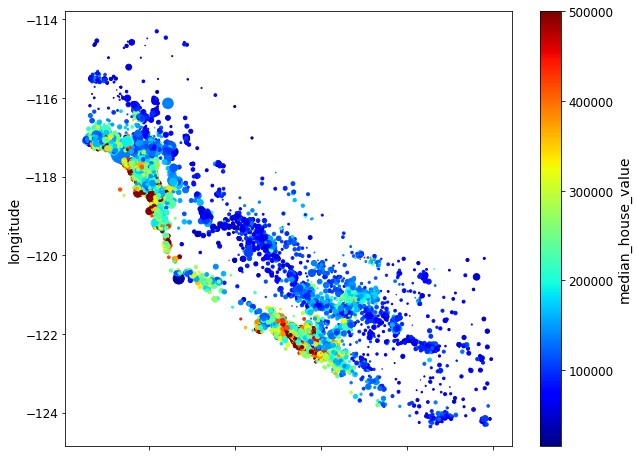

In [38]:
housing.plot(kind='scatter',x='latitude',y='longitude',c='median_house_value',cmap='jet',s=housing.population/100,figsize=(10,8))

In [39]:
corr_matrix=housing.corr()

In [40]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687160
total_rooms           0.135097
housing_median_age    0.114110
households            0.064506
total_bedrooms        0.047689
population           -0.026920
longitude            -0.047432
latitude             -0.142724
Name: median_house_value, dtype: float64

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f4362624fd0>,
      dtype=object)

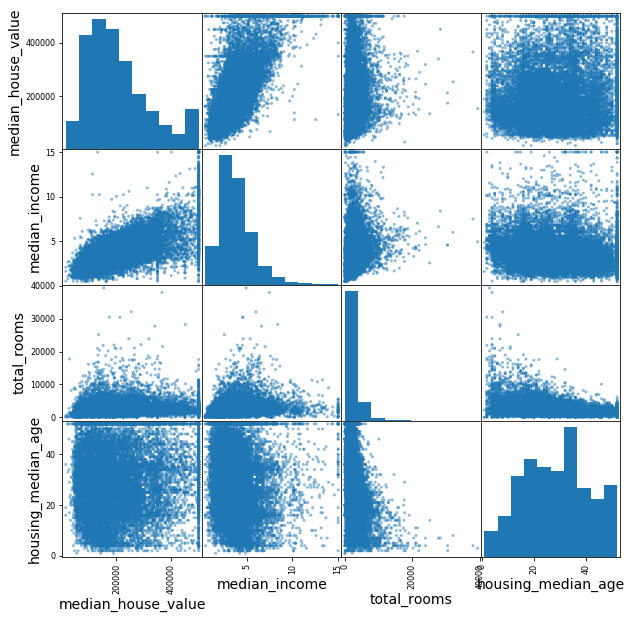

In [41]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes],figsize=(10,10))

In [42]:
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"]=housing["population"]/housing["households"]

In [43]:
print(len(housing.keys()))
print(housing.keys())

14
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'income_cat',
       'rooms_per_household', 'bedrooms_per_room', 'population_per_household'],
      dtype='object')


# Preparing data
We will add these attributes later again but setting everything as a pipeline dataflow.\
But first let us check for features that could cause problems for ML algorithms.\
There are two problems: a) missing values b) features that do not map to numbers.\
Also, we need to separate from the data the features we want to use for labels and leave only the features used for calculation

Let us remove the label from the data and create a "series" (dataframe with one feature) to use in fitting.\
We will do this in a fresh data set directly from the train_set generator.

In [44]:
housing = strat_train_set.drop("median_house_value", axis=1) # drop labels for training set
housing_labels = strat_train_set["median_house_value"].copy()

In [47]:
print(type(strat_train_set),strat_train_set.shape)
print(type(housing),housing.shape)
print(type(housing_labels),housing_labels.shape)

<class 'pandas.core.frame.DataFrame'> (16512, 11)
<class 'pandas.core.frame.DataFrame'> (16512, 10)
<class 'pandas.core.series.Series'> (16512,)


In [48]:
housing_labels[:5]

17606    286600.0
18632    340600.0
14650    196900.0
3230      46300.0
3555     254500.0
Name: median_house_value, dtype: float64

In [49]:
housing.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
17606,-121.89,37.29,38.0,1568.0,351.0,710.0,339.0,2.7042,<1H OCEAN,2
18632,-121.93,37.05,14.0,679.0,108.0,306.0,113.0,6.4214,<1H OCEAN,5
14650,-117.20,32.77,31.0,1952.0,471.0,936.0,462.0,2.8621,NEAR OCEAN,2
3230,-119.61,36.31,25.0,1847.0,371.0,1460.0,353.0,1.8839,INLAND,2
3555,-118.59,34.23,17.0,6592.0,1525.0,4459.0,1463.0,3.0347,<1H OCEAN,3


In [52]:
print(len(housing.keys()))
print(housing.keys())

10
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity', 'income_cat'],
      dtype='object')


Need to check for missing entries and remove them from the data or fill them up before ML algorithms

In [53]:
sample_incomplete_rows = housing[housing.isnull().any(axis=1)].head()
sample_incomplete_rows

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
4629,-118.30,34.07,18.0,3759.0,NaN,3296.0,1462.0,2.2708,<1H OCEAN,2
6068,-117.86,34.01,16.0,4632.0,NaN,3038.0,727.0,5.1762,<1H OCEAN,4
17923,-121.97,37.35,30.0,1955.0,NaN,999.0,386.0,4.6328,<1H OCEAN,4
13656,-117.30,34.05,6.0,2155.0,NaN,1039.0,391.0,1.6675,INLAND,2
19252,-122.79,38.48,7.0,6837.0,NaN,3468.0,1405.0,3.1662,<1H OCEAN,3


In [54]:
sample_incomplete_rows.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5 entries, 4629 to 19252
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           5 non-null      float64 
 1   latitude            5 non-null      float64 
 2   housing_median_age  5 non-null      float64 
 3   total_rooms         5 non-null      float64 
 4   total_bedrooms      0 non-null      float64 
 5   population          5 non-null      float64 
 6   households          5 non-null      float64 
 7   median_income       5 non-null      float64 
 8   ocean_proximity     5 non-null      object  
 9   income_cat          5 non-null      category
dtypes: category(1), float64(8), object(1)
memory usage: 605.0+ bytes


In this case we will fill them up with the median of all the other variables using the class Imputer

In [56]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

In [58]:
#imputer?

In [59]:
#but need to take out the string keys where the median does not work
housing_num = housing.drop("ocean_proximity", axis=1)

In [60]:
X=imputer.fit_transform(housing_num)

In [63]:
type(X),X.shape

(numpy.ndarray, (16512, 9))

The output from inputer is a ndarray, so we need to rebuild a panda dataframe

In [64]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,index=housing_num.index)

This data frame is the same as before except that the incomplete rows are filled in by the imputer.

In [67]:
housing_tr.loc[sample_incomplete_rows.index.values]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,income_cat
4629,-118.30,34.07,18.0,3759.0,433.0,3296.0,1462.0,2.2708,2.0
6068,-117.86,34.01,16.0,4632.0,433.0,3038.0,727.0,5.1762,4.0
17923,-121.97,37.35,30.0,1955.0,433.0,999.0,386.0,4.6328,4.0
13656,-117.30,34.05,6.0,2155.0,433.0,1039.0,391.0,1.6675,2.0
19252,-122.79,38.48,7.0,6837.0,433.0,3468.0,1405.0,3.1662,3.0


Let us check again, we got not left null values

In [68]:
housing_tr[housing_tr.isnull().any(axis=1)].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,income_cat


In [69]:
housing_tr.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16512 entries, 17606 to 15775
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   income_cat          16512 non-null  float64
dtypes: float64(9)
memory usage: 1.9 MB


In [70]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16512 entries, 17606 to 15775
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           16512 non-null  float64 
 1   latitude            16512 non-null  float64 
 2   housing_median_age  16512 non-null  float64 
 3   total_rooms         16512 non-null  float64 
 4   total_bedrooms      16354 non-null  float64 
 5   population          16512 non-null  float64 
 6   households          16512 non-null  float64 
 7   median_income       16512 non-null  float64 
 8   ocean_proximity     16512 non-null  object  
 9   income_cat          16512 non-null  category
dtypes: category(1), float64(8), object(1)
memory usage: 1.9+ MB


All these operations we did are going to be difficult to remember every time we have more data.\
sklearn provides pipelines, that are structures of processing steps.\
These processing steps have to be encapsulated in a method or a class.

In [82]:
from sklearn.base import BaseEstimator, TransformerMixin

# column index
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True): # no *args or **kargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self  # nothing else to do
    def transform(self, X):
        print("class CombinedAttributesAdder: input is a ",type(X))
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household,
                         bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(housing.values)

class CombinedAttributesAdder: input is a  <class 'numpy.ndarray'>


In [74]:
# Reminder, concatenating np.arrays with np.c_ 
aa=np.array([1,2])
bb=np.array([3,4])
aa=aa[:,np.newaxis]
bb=bb[:,np.newaxis]
cc=np.c_[aa,bb]
print(aa.shape,bb.shape,cc.shape)
print(cc)

(2, 1) (2, 1) (2, 2)
[[1 3]
 [2 4]]


In [85]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('attribs_adder', CombinedAttributesAdder()),
        ('std_scaler', StandardScaler()),
    ])

housing_tr = num_pipeline.fit_transform(housing_tr)

class CombinedAttributesAdder: input is a  <class 'numpy.ndarray'>


In [76]:
# notice that housing_tr is a ndarray (not dataframe)
print(type(housing_tr),housing_tr.shape)

<class 'numpy.ndarray'> (16512, 12)


Think of pipelines as a line of processes connected through pipes.\
Pipes are the typical communication method between programs in linux.\
Also, in R we saw pipes. The functions we saw in R using pipes are the equivalent of these pipelines.\
Pipelines are common in other environments, for example seismic processing packages.


## Let us run regression with several machine learning algorithms
We will start from the housing_num frame where we already dropped the non-numerical column ocean proximity.

In [79]:
housing_num.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,income_cat
17606,-121.89,37.29,38.0,1568.0,351.0,710.0,339.0,2.7042,2
18632,-121.93,37.05,14.0,679.0,108.0,306.0,113.0,6.4214,5
14650,-117.20,32.77,31.0,1952.0,471.0,936.0,462.0,2.8621,2
3230,-119.61,36.31,25.0,1847.0,371.0,1460.0,353.0,1.8839,2
3555,-118.59,34.23,17.0,6592.0,1525.0,4459.0,1463.0,3.0347,3


In [80]:
housing_labels[:5]

17606    286600.0
18632    340600.0
14650    196900.0
3230      46300.0
3555     254500.0
Name: median_house_value, dtype: float64

### Linear regression and decision tree
For each method we will start from housing with numbers only, run the pipeline that interpolates, adds attributes and scales.\
Then we just apply the linear regression algorithm from sklearn by using fit. 

In [92]:
from sklearn.linear_model import LinearRegression
print("housing_num",housing_num.shape,type(housing_num))
housing_prepared=num_pipeline.fit_transform(housing_num)
print("housing_prepared",housing_prepared.shape, housing_prepared.dtype)
print("housing_labels",housing_labels.shape, housing_labels.dtype)
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

housing_num (16512, 9) <class 'pandas.core.frame.DataFrame'>
class CombinedAttributesAdder: input is a  <class 'numpy.ndarray'>
housing_prepared (16512, 12) float64
housing_labels (16512,) float64


LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

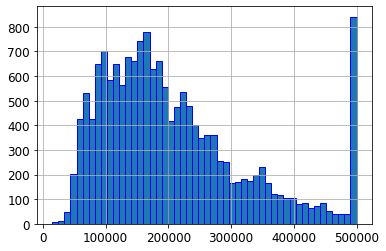

In [94]:
housing_labels.hist(bins=50,edgecolor='b')

In [102]:
# let's try the full preprocessing pipeline on a few training instances
some_data = housing_num[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = num_pipeline.transform(some_data)
predictions=lin_reg.predict(some_data_prepared)
print("labels - predictions\n"),[print('{:.0f}'.format(housing_labels[i]),'{:.0f}'.format(predictions[i])) for i in range(5)]
print()

class CombinedAttributesAdder: input is a  <class 'numpy.ndarray'>
labels - predictions

452600 199438
358500 328309
352100 197891
341300 70316
342200 190974



In [103]:
print(type(some_data),type(some_labels),type(some_data_prepared),type(predictions))


<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.series.Series'> <class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [104]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
17606,-121.89,37.29,38.0,1568.0,351.0,710.0,339.0,2.7042,<1H OCEAN,2
18632,-121.93,37.05,14.0,679.0,108.0,306.0,113.0,6.4214,<1H OCEAN,5
14650,-117.20,32.77,31.0,1952.0,471.0,936.0,462.0,2.8621,NEAR OCEAN,2
3230,-119.61,36.31,25.0,1847.0,371.0,1460.0,353.0,1.8839,INLAND,2
3555,-118.59,34.23,17.0,6592.0,1525.0,4459.0,1463.0,3.0347,<1H OCEAN,3


In [105]:
some_labels.head()

17606    286600.0
18632    340600.0
14650    196900.0
3230      46300.0
3555     254500.0
Name: median_house_value, dtype: float64

Let us evaluate how good the Mean Squared Error (MSE) is when all data are considered

In [106]:
from sklearn.metrics import mean_squared_error
housing_prepared=num_pipeline.transform(housing_num)
housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

class CombinedAttributesAdder: input is a  <class 'numpy.ndarray'>


69122.55251656997

The score for the linear regressor is not great. Let us try a decision tree:

In [108]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_prepared, housing_labels)

DecisionTreeRegressor(ccp_alpha=0.0, criterion='mse', max_depth=None,
                      max_features=None, max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=1, min_samples_split=2,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=42, splitter='best')

In [109]:
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

0.0

An error of zero it probably means overfitting. We need to use a more objective measure than just the data
where the regressor was calculated. We could use the validation and test datasets.
Another more automatic way of doing this, is using cross-validation. 
The data are separated on a training and test data sets many times, and each time the
algorithm is trained again. 

### Cross-Validation

In [110]:
from sklearn.model_selection import cross_val_score
tree_scores = cross_val_score(tree_reg, housing_prepared, housing_labels,scoring="neg_mean_squared_error", cv=10)

In [111]:
# to visualize the scores we can use a panda series like this
pd.Series(np.sqrt(-tree_scores)).describe()

count       10.000000
mean     74121.686152
std       1588.129883
min      71696.829207
25%      72891.486498
50%      74310.920704
75%      75014.837211
max      77207.527889
dtype: float64

In [112]:
# or we can create a customized function
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())
    
tree_rmse_scores = np.sqrt(-tree_scores)
display_scores(tree_rmse_scores)

Scores: [72882.51847455 74596.15140555 75121.03921383 74025.69000219
 74862.33108872 75065.67258506 72918.39056875 71696.82920653
 72840.71108302 77207.52788905]
Mean: 74121.68615172496
Standard deviation: 1506.632295578998


In [113]:
#let us repeat for the linear regressor
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error",cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)

In [114]:
display_scores(lin_rmse_scores)

Scores: [67378.79042214 67574.49475862 72241.91999709 74366.43260863
 68140.38287587 71502.66022925 65795.80759686 68656.8280025
 71911.0075619  68414.9564013 ]
Mean: 69598.3280454162
Standard deviation: 2580.545915827455


We see that the linear regressor in reality did better than the regression tree.
A regression tree alone is not that powerful to generalize because it tends to overfit.
We will see that in future lectures. 
However, a more powerful device that uses trees is a Random forest. 

In [115]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(housing_prepared, housing_labels)

RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='mse',
                      max_depth=None, max_features='auto', max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=100, n_jobs=None, oob_score=False,
                      random_state=42, verbose=0, warm_start=False)

In [116]:
housing_predictions = forest_reg.predict(housing_prepared)
forest_mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

18969.8243756475

In [117]:
forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error",cv=10)

In [118]:
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Scores: [50281.33985873 48536.1261216  50317.95704951 53036.08342706
 50138.46019717 53982.89992499 48979.35853665 49543.50331463
 54184.48013774 52230.6009476 ]
Mean: 51123.080951567434
Standard deviation: 1963.315709236616


In [119]:
from sklearn.svm import SVR
svm_reg = SVR(kernel="linear")
svm_reg.fit(housing_prepared, housing_labels)
housing_predictions = svm_reg.predict(housing_prepared)
svm_mse = mean_squared_error(housing_labels, housing_predictions)
svm_rmse = np.sqrt(svm_mse)
svm_rmse

107825.37956502863

### GRID SEARCH
This process could take a long time because each method has many options to optimize.
To automatize this tuning process skit-learn has a function that can systematically try ranges of parameters
combined with cross-validations


In [120]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    # try 12 (3×4) combinations of hyperparameters
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    # then try 6 (2×3) combinations with bootstrap set as False
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
  ]

forest_reg = RandomForestRegressor(random_state=42)
# train across 5 folds, that's a total of (12+6)*5=90 rounds of training 
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(housing_prepared, housing_labels)

GridSearchCV(cv=5, error_score=nan,
             estimator=RandomForestRegressor(bootstrap=True, ccp_alpha=0.0,
                                             criterion='mse', max_depth=None,
                                             max_features='auto',
                                             max_leaf_nodes=None,
                                             max_samples=None,
                                             min_impurity_decrease=0.0,
                                             min_impurity_split=None,
                                             min_samples_leaf=1,
                                             min_samples_split=2,
                                             min_weight_fraction_leaf=0.0,
                                             n_estimators=100, n_jobs=None,
                                             oob_score=False, random_state=42,
                                             verbose=0, warm_start=False),
             iid='deprecated', n_jobs

In [121]:
# Best parameters
grid_search.best_params_

{'max_features': 8, 'n_estimators': 30}

In [122]:
# Best estimator
grid_search.best_estimator_

RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='mse',
                      max_depth=None, max_features=8, max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=30, n_jobs=None, oob_score=False,
                      random_state=42, verbose=0, warm_start=False)

In [123]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print('{:.0f}'.format(np.sqrt(-mean_score)), params)

68127 {'max_features': 2, 'n_estimators': 3}
58668 {'max_features': 2, 'n_estimators': 10}
55958 {'max_features': 2, 'n_estimators': 30}
64158 {'max_features': 4, 'n_estimators': 3}
56456 {'max_features': 4, 'n_estimators': 10}
53535 {'max_features': 4, 'n_estimators': 30}
62238 {'max_features': 6, 'n_estimators': 3}
55220 {'max_features': 6, 'n_estimators': 10}
52993 {'max_features': 6, 'n_estimators': 30}
61864 {'max_features': 8, 'n_estimators': 3}
55133 {'max_features': 8, 'n_estimators': 10}
52709 {'max_features': 8, 'n_estimators': 30}
66272 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
57541 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
63850 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
55381 {'bootstrap': False, 'max_features': 3, 'n_estimators': 10}
61454 {'bootstrap': False, 'max_features': 4, 'n_estimators': 3}
54978 {'bootstrap': False, 'max_features': 4, 'n_estimators': 10}


there are ways to search the whole model space that could improve this result but for this test
let us settle with this result:

In [124]:
final_model = grid_search.best_estimator_

Now we will finish the predictions with this estimator.
We will take the strat_test_set and apply the preprocessing:

In [125]:
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()
#but need to take out the string keys where the median does not work
X_test_num = X_test.drop("ocean_proximity", axis=1)
X_test_prepared = num_pipeline.transform(X_test_num)

class CombinedAttributesAdder: input is a  <class 'numpy.ndarray'>


In [126]:
final_predictions = final_model.predict(X_test_prepared)

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

In [127]:
print(final_rmse)

50724.71131195644


In [128]:
y_testl=list(y_test)

In [129]:
print('predictions, labels')
[print('{:.0f}\t{:.0f}'.format(final_predictions[i], y_testl[i])) for i in range(10)]
print()

predictions, labels
496357	500001
266550	240300
255947	218200
195793	182100
135597	121300
145480	120600
66793	72300
405650	500001
103427	98900
93967	82600

